## Análise estatística completa dos resultados de exposição a LLMs

Este notebook realiza uma análise estatística abrangente dos scores de exposição ocupacional a LLMs presentes em `score_results.csv`, seguindo a estrutura do experimento e os objetivos definidos para a seção de resultados de um TCC.

A análise inclui: carregamento e validação da base, limpeza e preparação, estatísticas descritivas, avaliação de estabilidade intra-modelo, comparação entre modelos, medidas de concordância, testes estatísticos, visualizações gráficas e tabelas-resumo exportáveis.

### 1. Importação e configuração

Nesta seção importamos as bibliotecas necessárias e configuramos a exibição de tabelas e gráficos.

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

try:
    import statsmodels.api as sm
    import statsmodels.stats.inter_rater as irr
except ImportError:
    sm = None
    irr = None

try:
    from sklearn.metrics import cohen_kappa_score
except ImportError:
    cohen_kappa_score = None

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

def find_base_dir() -> Path:
    """Tenta localizar o diretório base onde está o `score_results.csv`.

    Isso torna o notebook robusto quando o usuário executa as células a partir
    de outra pasta (por exemplo, `analise_resultados`).
    """
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for c in candidates:
        if (c / "dados" / "score_results.csv").exists():
            return c
    raise FileNotFoundError(
        "Não foi possível localizar `score_results.csv`. "
        "Verifique se o arquivo está em `dados_cbo/score_results.csv` ou "
        "ajuste o caminho no notebook."
    )

BASE_DIR = find_base_dir()
INPUT_FILE = BASE_DIR / "dados" / "score_results.csv"
OUTPUT_DIR_TABELAS = BASE_DIR / "resultados" / "tabelas"
OUTPUT_DIR_GRAFICOS = BASE_DIR / "resultados" / "graficos"
OUTPUT_DIR = BASE_DIR / "resultados"  # compatibilidade
OUTPUT_DIR_TABELAS.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR_GRAFICOS.mkdir(parents=True, exist_ok=True)

### 2. Leitura e validação da base

Carregamos o arquivo `score_results.csv`, inspecionamos dimensões, tipos de colunas, valores ausentes, duplicatas e verificamos se a estrutura do experimento está coerente com o planejado (30 ocupações, 150 atividades, 2 modelos, 2 rodadas por modelo, 600 linhas).

In [3]:
REQUIRED_COLUMNS = [
    "ocupacao",
    "atividade",
    "modelo",
    "rodada",
    "score",
    "justificativa",
    "timestamp",
]

def load_and_validate(path: Path) -> pd.DataFrame:
    """Carrega o CSV, padroniza colunas e valida estrutura básica."""
    if not path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {path}")

    df = pd.read_csv(path, encoding="utf-8")

    # Remover espaços extras nos nomes das colunas
    df.columns = df.columns.str.strip()

    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        raise ValueError(
            f"Colunas obrigatórias ausentes: {missing_cols}. Colunas presentes: {list(df.columns)}"
        )

    return df

df_raw = load_and_validate(INPUT_FILE)

print("Dimensões da base (linhas, colunas):", df_raw.shape)
display(df_raw.head())
print("\nTipos das colunas:")
display(df_raw.dtypes)

print("\nValores ausentes por coluna:")
display(df_raw.isna().sum())

print("\nNúmero de linhas duplicadas (considerando todas as colunas):")
print(df_raw.duplicated().sum())

Dimensões da base (linhas, colunas): (600, 7)


,ocupacao,atividade,modelo,rodada,score,justificativa,timestamp
0,Analista de planejamento e orçamento - apo,Subsidiar elaboração de diretrizes de política...,gpt-4o-mini,1,2.0,"LLM pode auxiliar na elaboração, mas requer ju...",2026-03-13T21:45:00Z
1,Analista de planejamento e orçamento - apo,Subsidiar elaboração de diretrizes de política...,gpt-4o-mini,2,1.0,Núcleo exige julgamento humano complexo e inte...,2026-03-13T21:45:01Z
2,Analista de planejamento e orçamento - apo,Subsidiar elaboração de diretrizes de política...,claude-3-haiku-20240307,1,2.0,A atividade exige julgamento humano complexo e...,2026-03-13T21:45:01Z
3,Analista de planejamento e orçamento - apo,Subsidiar elaboração de diretrizes de política...,claude-3-haiku-20240307,2,2.0,A atividade exige julgamento humano complexo e...,2026-03-13T21:45:02Z
4,Analista de planejamento e orçamento - apo,Avaliar processo orçamentário,gpt-4o-mini,1,2.0,"LLM pode auxiliar na análise, mas julgamento h...",2026-03-13T21:45:03Z



Tipos das colunas:


ocupacao             str
atividade            str
modelo               str
rodada             int64
score            float64
justificativa        str
timestamp            str
dtype: object


Valores ausentes por coluna:


ocupacao         0
atividade        0
modelo           0
rodada           0
score            0
justificativa    0
timestamp        0
dtype: int64


Número de linhas duplicadas (considerando todas as colunas):
0


In [4]:
# Verificações estruturais do experimento
n_ocupacoes = df_raw["ocupacao"].nunique()
n_atividades = df_raw[["ocupacao", "atividade"]].drop_duplicates().shape[0]
n_modelos = df_raw["modelo"].nunique()
n_rodadas = df_raw["rodada"].nunique()
n_linhas = len(df_raw)

print("Número de ocupações:", n_ocupacoes)
print("Número de atividades únicas (ocupacao + atividade):", n_atividades)
print("Número de modelos:", n_modelos)
print("Número de rodadas distintas:", n_rodadas)
print("Número de linhas:", n_linhas)

# Verificar se há exatamente 2 rodadas por modelo e atividade
checks = (
    df_raw.groupby(["ocupacao", "atividade", "modelo"])  # agrupamento fino
    ["rodada"]
    .nunique()
    .rename("n_rodadas_distintas")
)

print("\nDistribuição de número de rodadas distintas por (ocupacao, atividade, modelo):")
display(checks.value_counts().to_frame("quantidade_grupos"))

expected_n_linhas = 30 * 5 * 2 * 2  # 30 ocupações × 5 atividades × 2 modelos × 2 rodadas
print("\nTotal esperado de linhas:", expected_n_linhas)
if n_linhas != expected_n_linhas:
    print("ATENÇÃO: número de linhas diferente do esperado!")
else:
    print("Estrutura de linhas compatível com o experimento planejado.")

Número de ocupações: 30
Número de atividades únicas (ocupacao + atividade): 150
Número de modelos: 2
Número de rodadas distintas: 2
Número de linhas: 600

Distribuição de número de rodadas distintas por (ocupacao, atividade, modelo):


,quantidade_grupos
n_rodadas_distintas,
2,300



Total esperado de linhas: 600
Estrutura de linhas compatível com o experimento planejado.


_Interpretação breve_: Esta etapa verifica se a base está consistente com o desenho experimental (número de ocupações, atividades, modelos, rodadas e total de observações). Inconsistências aqui podem indicar problemas de coleta ou de pré-processamento que afetam todas as análises seguintes.

### 3. Limpeza e preparação dos dados

Nesta seção garantimos que a coluna `score` seja numérica, padronizamos etiquetas de modelos e rodadas quando necessário, criamos identificadores úteis e versões em formato longo e wide.

In [5]:
df = df_raw.copy()

# Garantir que score é numérico
df["score"] = pd.to_numeric(df["score"], errors="coerce")

n_missing_score = df["score"].isna().sum()
print("Linhas com score ausente (após conversão para numérico):", n_missing_score)

# Manter uma versão completa e outra filtrada para análises que exigem score
df_valid = df.dropna(subset=["score"]).copy()
print("Linhas válidas para análise de score:", len(df_valid))

# Padronizar modelo e rodada (se necessário)
df_valid["modelo"] = df_valid["modelo"].astype(str).str.strip()
df_valid["rodada"] = df_valid["rodada"].astype(int)

# Criar identificador único de atividade (ocupacao + atividade)
df_valid["id_atividade"] = (
    df_valid["ocupacao"].astype(str).str.strip()
    + " | "
    + df_valid["atividade"].astype(str).str.strip()
)

print("Número de id_atividade distintos:", df_valid["id_atividade"].nunique())
display(df_valid.head())

Linhas com score ausente (após conversão para numérico): 0
Linhas válidas para análise de score: 600
Número de id_atividade distintos: 150


,ocupacao,atividade,modelo,rodada,score,justificativa,timestamp,id_atividade
0,Analista de planejamento e orçamento - apo,Subsidiar elaboração de diretrizes de política...,gpt-4o-mini,1,2.0,"LLM pode auxiliar na elaboração, mas requer ju...",2026-03-13T21:45:00Z,Analista de planejamento e orçamento - apo | S...
1,Analista de planejamento e orçamento - apo,Subsidiar elaboração de diretrizes de política...,gpt-4o-mini,2,1.0,Núcleo exige julgamento humano complexo e inte...,2026-03-13T21:45:01Z,Analista de planejamento e orçamento - apo | S...
2,Analista de planejamento e orçamento - apo,Subsidiar elaboração de diretrizes de política...,claude-3-haiku-20240307,1,2.0,A atividade exige julgamento humano complexo e...,2026-03-13T21:45:01Z,Analista de planejamento e orçamento - apo | S...
3,Analista de planejamento e orçamento - apo,Subsidiar elaboração de diretrizes de política...,claude-3-haiku-20240307,2,2.0,A atividade exige julgamento humano complexo e...,2026-03-13T21:45:02Z,Analista de planejamento e orçamento - apo | S...
4,Analista de planejamento e orçamento - apo,Avaliar processo orçamentário,gpt-4o-mini,1,2.0,"LLM pode auxiliar na análise, mas julgamento h...",2026-03-13T21:45:03Z,Analista de planejamento e orçamento - apo | A...


_Interpretação breve_: A limpeza garante que `score` esteja em formato numérico e que as chaves de agrupamento (ocupação, atividade, modelo, rodada) estejam padronizadas, reduzindo o risco de erros silenciosos nas análises de variabilidade e concordância.

### 4. Estatística descritiva completa dos scores

Aqui calculamos estatísticas descritivas (contagem, média, mediana, moda, mínimo, máximo, amplitude, variância, desvio padrão, coeficiente de variação, quartis e IQR) para o conjunto total de scores e para recortes relevantes (por modelo, rodada e combinação modelo–rodada).

In [6]:
def descriptive_stats(series: pd.Series) -> pd.Series:
    """Calcula estatísticas descritivas estendidas para uma série numérica."""
    s = series.dropna()
    if s.empty:
        return pd.Series(dtype=float)

    count = s.count()
    mean = s.mean()
    median = s.median()
    mode_vals = s.mode()
    mode = mode_vals.iloc[0] if not mode_vals.empty else np.nan
    min_ = s.min()
    max_ = s.max()
    amplitude = max_ - min_
    var_ = s.var(ddof=1)
    std_ = s.std(ddof=1)
    cv = std_ / mean if mean != 0 else np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    return pd.Series(
        {
            "count": count,
            "mean": mean,
            "median": median,
            "mode": mode,
            "min": min_,
            "max": max_,
            "amplitude": amplitude,
            "var": var_,
            "std": std_,
            "cv": cv,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
        }
    )


# Estatísticas gerais
stats_gerais = descriptive_stats(df_valid["score"])
display(stats_gerais.to_frame("geral"))

# Por modelo
stats_por_modelo = df_valid.groupby("modelo")["score"].apply(descriptive_stats).unstack()
display(stats_por_modelo)

# Por rodada
stats_por_rodada = df_valid.groupby("rodada")["score"].apply(descriptive_stats).unstack()
display(stats_por_rodada)

# Por modelo e rodada
stats_modelo_rodada = (
    df_valid.groupby(["modelo", "rodada"])["score"].apply(descriptive_stats).unstack()
)
display(stats_modelo_rodada)

# Opcional: por ocupação (média e desvio padrão)
stats_por_ocupacao = df_valid.groupby("ocupacao")["score"].agg([
    "count",
    "mean",
    "std",
    "median",
])
display(stats_por_ocupacao.head())

# Salvar estatísticas em CSV
stats_por_modelo.to_csv(OUTPUT_DIR_TABELAS / "estatisticas_por_modelo.csv")
stats_por_rodada.to_csv(OUTPUT_DIR_TABELAS / "estatisticas_por_rodada.csv")
stats_modelo_rodada.to_csv(OUTPUT_DIR_TABELAS / "estatisticas_por_modelo_rodada.csv")
stats_por_ocupacao.to_csv(OUTPUT_DIR_TABELAS / "estatisticas_por_ocupacao.csv")

,geral
count,600.000000
mean,1.611667
median,2.000000
mode,2.000000
min,0.000000
max,3.000000
amplitude,3.000000
var,0.341433
std,0.584323
cv,0.362558


,count,mean,median,mode,min,max,amplitude,var,std,cv,q1,q3,iqr
modelo,,,,,,,,,,,,,
claude-3-haiku-20240307,300.0,1.813333,2.0,2.0,1.0,3.0,2.0,0.199153,0.446265,0.246102,2.0,2.0,0.0
gpt-4o-mini,300.0,1.410000,1.0,1.0,0.0,3.0,3.0,0.403244,0.635015,0.450365,1.0,2.0,1.0


,count,mean,median,mode,min,max,amplitude,var,std,cv,q1,q3,iqr
rodada,,,,,,,,,,,,,
1,300.0,1.613333,2.0,2.0,0.0,3.0,3.0,0.344972,0.587343,0.364056,1.0,2.0,1.0
2,300.0,1.610000,2.0,2.0,0.0,3.0,3.0,0.339030,0.582263,0.361654,1.0,2.0,1.0


count      mean  median  mode  min  max  amplitude       var       std        cv   q1  \
modelo                  rodada                                                                                          
claude-3-haiku-20240307 1       150.0  1.813333     2.0   2.0  1.0  3.0        2.0  0.206532  0.454458  0.250620  2.0   
                        2       150.0  1.813333     2.0   2.0  1.0  3.0        2.0  0.193110  0.439442  0.242340  2.0   
gpt-4o-mini             1       150.0  1.413333     1.0   1.0  0.0  3.0        3.0  0.405190  0.636545  0.450386  1.0   
                        2       150.0  1.406667     1.0   1.0  0.0  3.0        3.0  0.403982  0.635596  0.451845  1.0   

                                 q3  iqr  
modelo                  rodada            
claude-3-haiku-20240307 1       2.0  0.0  
                        2       2.0  0.0  
gpt-4o-mini             1       2.0  1.0  
                        2       2.0  1.0

,count,mean,std,median
ocupacao,,,,
Administrador,20,1.90,0.307794,2.0
Advogado,20,1.15,0.670820,1.0
Analista de desenvolvimento de sistemas,20,1.80,0.767772,2.0
Analista de logistica,20,1.80,0.410391,2.0
Analista de pesquisa de mercado,20,1.70,0.470162,2.0


_Interpretação breve_: As estatísticas descritivas mostram o nível médio dos scores, sua dispersão (desvio padrão, coeficiente de variação, IQR) e a posição da distribuição (mediana, quartis). Diferenças relevantes entre modelos ou rodadas podem sugerir vieses sistemáticos ou instabilidade na atribuição de scores.

### 5. Variação intra-modelo entre rodadas

Nesta seção medimos a estabilidade de cada modelo ao reavaliar a mesma atividade em duas rodadas. As análises são feitas separadamente por modelo, garantindo que o pareamento sempre use a mesma atividade e o mesmo modelo.

In [7]:
def intra_model_differences(df_model: pd.DataFrame) -> pd.DataFrame:
    """Calcula diferenças entre rodadas 1 e 2 para um único modelo."""
    wide = (
        df_model
        .pivot_table(
            index=["id_atividade"],
            columns="rodada",
            values="score",
        )
        .rename(columns={1: "score_r1", 2: "score_r2"})
    )

    wide = wide.dropna(subset=["score_r1", "score_r2"])  # garantir pareamento completo

    wide["diff"] = wide["score_r2"] - wide["score_r1"]
    wide["diff_abs"] = wide["diff"].abs()

    return wide


res_intra = {}
res_intra_summaries = []

for modelo, df_m in df_valid.groupby("modelo"):
    wide = intra_model_differences(df_m)
    res_intra[modelo] = wide

    diffs = wide["diff"]
    diffs_abs = wide["diff_abs"]

    mae = diffs_abs.mean()
    rmse = np.sqrt((diffs ** 2).mean())
    corr_pearson = diffs.corr(wide["score_r1"] + wide["score_r2"] * 0)  # placeholder
    # Correlação entre rodada 1 e rodada 2
    corr_r1_r2 = wide["score_r1"].corr(wide["score_r2"])

    summary = {
        "modelo": modelo,
        "n_atividades": len(wide),
        "media_diff_abs": diffs_abs.mean(),
        "mediana_diff_abs": diffs_abs.median(),
        "std_diff": diffs.std(ddof=1),
        "var_diff": diffs.var(ddof=1),
        "mae": mae,
        "rmse": rmse,
        "corr_r1_r2": corr_r1_r2,
    }
    res_intra_summaries.append(summary)

df_intra_summary = pd.DataFrame(res_intra_summaries)
display(df_intra_summary)
df_intra_summary.to_csv(OUTPUT_DIR_TABELAS / "intra_modelo_resumo.csv", index=False)

# Identificar atividades com maior instabilidade por modelo
top_instaveis = []
for modelo, wide in res_intra.items():
    tmp = wide.copy()
    tmp["modelo"] = modelo
    top_instaveis.append(tmp.sort_values("diff_abs", ascending=False).head(10))

df_top_instaveis = pd.concat(top_instaveis, axis=0)
display(df_top_instaveis.head(20))
df_top_instaveis.to_csv(OUTPUT_DIR_TABELAS / "atividades_mais_instaveis_intra_modelo.csv")

,modelo,n_atividades,media_diff_abs,mediana_diff_abs,std_diff,var_diff,mae,rmse,corr_r1_r2
0,claude-3-haiku-20240307,150,0.013333,0.0,0.115857,0.013423,0.013333,0.115470,0.966958
1,gpt-4o-mini,150,0.033333,0.0,0.183064,0.033512,0.033333,0.182574,0.958586


rodada,score_r1,score_r2,diff,diff_abs,modelo
id_atividade,,,,,
Economista | Recrutar equipe,1.0,2.0,1.0,1.0,claude-3-haiku-20240307
"Analista financeiro (instituições financeiras) | Apurar taxas médias, prazos e saldos médios das carteiras",3.0,2.0,-1.0,1.0,claude-3-haiku-20240307
Administrador | Estabelecer metodologia de avaliação,2.0,2.0,0.0,0.0,claude-3-haiku-20240307
Administrador | Estabelecer rotinas de trabalho,2.0,2.0,0.0,0.0,claude-3-haiku-20240307
Administrador | Avaliar viabilidade de projetos,2.0,2.0,0.0,0.0,claude-3-haiku-20240307
Administrador | Demonstrar capacidade de comunicação,2.0,2.0,0.0,0.0,claude-3-haiku-20240307
"Advogado | Analisar, fatos, relatórios e documentos",2.0,2.0,0.0,0.0,claude-3-haiku-20240307
Advogado | Cumprir prazos legais,2.0,2.0,0.0,0.0,claude-3-haiku-20240307
Advogado | Demonstrar criatividade,1.0,1.0,0.0,0.0,claude-3-haiku-20240307


_Interpretação breve_: Diferenças pequenas entre rodadas dentro de um mesmo modelo indicam maior estabilidade e reprodutibilidade das avaliações. Diferenças grandes (especialmente concentradas em certas atividades) sugerem que o modelo é sensível ao ruído de prompt ou à formulação da tarefa.

### 6. Variação entre modelos para a mesma atividade

Agora comparamos os modelos entre si, para cada atividade. Utilizamos como medida principal o score médio das duas rodadas de cada modelo para cada atividade, e calculamos diferenças simples e absolutas entre os modelos.

In [8]:
# Média por modelo em cada atividade (média das duas rodadas)
df_media_modelo_atividade = (
    df_valid
    .groupby(["id_atividade", "modelo"])["score"]
    .mean()
    .rename("score_medio_modelo")
    .reset_index()
)

# Transformar em formato wide: uma coluna por modelo
df_modelos_wide = df_media_modelo_atividade.pivot(
    index="id_atividade",
    columns="modelo",
    values="score_medio_modelo",
)
df_modelos_wide = df_modelos_wide.dropna()  # manter apenas atividades avaliadas pelos dois modelos

# Assumimos dois modelos A e B (nomes conforme aparecem no CSV)
model_names = list(df_modelos_wide.columns)
if len(model_names) != 2:
    print("ATENÇÃO: número de modelos != 2. As análises seguintes assumem dois modelos.")

m1, m2 = model_names[0], model_names[1]

df_modelos_wide["diff_modelos"] = df_modelos_wide[m2] - df_modelos_wide[m1]
df_modelos_wide["diff_modelos_abs"] = df_modelos_wide["diff_modelos"].abs()

diffs = df_modelos_wide["diff_modelos"]
diffs_abs = df_modelos_wide["diff_modelos_abs"]

mae_modelos = diffs_abs.mean()
rmse_modelos = np.sqrt((diffs ** 2).mean())
corr_medias = df_modelos_wide[m1].corr(df_modelos_wide[m2])

res_between_models = pd.Series(
    {
        "media_diff": diffs.mean(),
        "mediana_diff": diffs.median(),
        "std_diff": diffs.std(ddof=1),
        "var_diff": diffs.var(ddof=1),
        "mae": mae_modelos,
        "rmse": rmse_modelos,
        "corr_medias": corr_medias,
        "n_atividades": len(df_modelos_wide),
    }
)
display(res_between_models.to_frame("comparacao_modelos"))
df_modelos_wide.to_csv(OUTPUT_DIR_TABELAS / "comparacao_modelos_por_atividade.csv")

# Comparação por rodada (modelo A rodada 1 vs modelo B rodada 1, etc.)
df_wide_round = (
    df_valid
    .pivot_table(
        index=["id_atividade", "rodada"],
        columns="modelo",
        values="score",
    )
    .dropna()
)

comparacoes_rodada = []
for rodada, sub in df_wide_round.groupby(level="rodada"):
    s1 = sub[m1]
    s2 = sub[m2]
    diff = s2 - s1
    diff_abs = diff.abs()
    mae = diff_abs.mean()
    rmse = np.sqrt((diff ** 2).mean())
    corr = s1.corr(s2)
    comparacoes_rodada.append(
        {
            "rodada": rodada,
            "media_diff": diff.mean(),
            "mediana_diff": diff.median(),
            "std_diff": diff.std(ddof=1),
            "mae": mae,
            "rmse": rmse,
            "corr": corr,
            "n_atividades": len(sub),
        }
    )

df_comparacao_rodadas = pd.DataFrame(comparacoes_rodada)
display(df_comparacao_rodadas)
df_comparacao_rodadas.to_csv(OUTPUT_DIR_TABELAS / "comparacao_modelos_por_rodada.csv", index=False)

,comparacao_modelos
media_diff,-0.403333
mediana_diff,0.000000
std_diff,0.551680
var_diff,0.304351
mae,0.456667
rmse,0.681909
corr_medias,0.516706
n_atividades,150.000000


,rodada,media_diff,mediana_diff,std_diff,mae,rmse,corr,n_atividades
0,1,-0.400000,0.0,0.555630,0.453333,0.683130,0.523704,150
1,2,-0.406667,0.0,0.568722,0.460000,0.697615,0.489866,150


_Interpretação breve_: Diferenças sistemáticas entre os scores médios dos modelos indicam divergências na forma como cada LLM avalia a exposição das mesmas atividades. MAE e RMSE captam o tamanho médio dessas discrepâncias, enquanto a correlação mostra se os modelos mantêm uma ordenação semelhante das atividades em termos de exposição.

### 7. Medidas de correspondência e concordância entre modelos

Nesta etapa avaliamos o grau de semelhança entre os modelos usando diferentes métricas, considerando a natureza dos scores. Como os scores são discretos em escala limitada, tratamos-nos como variáveis numéricas ordinais: usamos correlações de Pearson e Spearman, e, quando disponível, medidas de concordância como ICC e Kappa ponderado.

In [9]:
# Usaremos a tabela df_modelos_wide (médias por atividade)
scores_m1 = df_modelos_wide[m1]
scores_m2 = df_modelos_wide[m2]

pearson_corr, pearson_p = stats.pearsonr(scores_m1, scores_m2)
spearman_corr, spearman_p = stats.spearmanr(scores_m1, scores_m2)

results_concord = {
    "pearson_r": pearson_corr,
    "pearson_p": pearson_p,
    "spearman_rho": spearman_corr,
    "spearman_p": spearman_p,
}

# ICC (Intraclass Correlation Coefficient) para dois avaliadores (modelos)
# ICC(2,1): two-way random effects, single measure — adequado para comparar dois raters.
def icc_2_1(rater1: pd.Series, rater2: pd.Series) -> float:
    """Calcula ICC(2,1) a partir de duas colunas de scores (um valor por sujeito por rater)."""
    df_icc = pd.DataFrame({"r1": rater1, "r2": rater2}).dropna()
    n = len(df_icc)
    k = 2
    if n < 2:
        return np.nan
    grand_mean = df_icc.values.mean()
    subject_means = df_icc.mean(axis=1)
    ms_between = k * ((subject_means - grand_mean) ** 2).sum() / (n - 1)
    ms_within = ((df_icc["r1"] - subject_means) ** 2 + (df_icc["r2"] - subject_means) ** 2).sum() / (n * (k - 1))
    if (ms_between + ms_within) == 0:
        return np.nan
    return (ms_between - ms_within) / (ms_between + ms_within)

icc_res = icc_2_1(scores_m1, scores_m2)
results_concord["ICC_2_1"] = icc_res

# Cohen's Kappa ponderado, se sklearn estiver disponível
if cohen_kappa_score is not None:
    kappa_weighted = cohen_kappa_score(
        scores_m1.round().astype(int),
        scores_m2.round().astype(int),
        weights="quadratic",
    )
    results_concord["cohen_kappa_weighted"] = kappa_weighted
else:
    print("sklearn não disponível: Cohen's Kappa não será calculado.")

# Concordância exata e com tolerância
diffs_all = (scores_m2 - scores_m1).abs()
concord_exata = (diffs_all == 0).mean()
concord_tol_05 = (diffs_all <= 0.5).mean()
concord_tol_10 = (diffs_all <= 1.0).mean()

results_concord["concordancia_exata"] = concord_exata
results_concord["concordancia_tol_0_5"] = concord_tol_05
results_concord["concordancia_tol_1_0"] = concord_tol_10

df_concord = pd.Series(results_concord).to_frame("metricas_concordancia")
display(df_concord)
df_concord.to_csv(OUTPUT_DIR_TABELAS / "concordancia_entre_modelos.csv")

,metricas_concordancia
pearson_r,5.167059e-01
pearson_p,1.298872e-11
spearman_rho,4.896946e-01
spearman_p,2.023181e-10
ICC_2_1,3.090616e-01
cohen_kappa_weighted,3.747105e-01
concordancia_exata,5.333333e-01
concordancia_tol_0_5,5.733333e-01
concordancia_tol_1_0,9.866667e-01


_Interpretação breve_: Correlações altas indicam que os modelos ordenam as atividades de forma semelhante, mesmo que usem níveis absolutos diferentes de score. Medidas de concordância (como Kappa ponderado) são mais exigentes e captam se os modelos atribuem valores muito próximos na escala discreta de score.

### 8. Testes estatísticos

Aplicamos testes estatísticos pareados para comparar:
- rodada 1 vs rodada 2 dentro de cada modelo (estabilidade intra-modelo);
- modelo 1 vs modelo 2, usando as médias por atividade.

A escolha entre teste *t* pareado e Wilcoxon signed-rank é feita com base em uma verificação simples de normalidade das diferenças (teste de Shapiro-Wilk).

In [10]:
def paired_test(x: pd.Series, y: pd.Series, alpha: float = 0.05) -> dict:
    """Executa teste t pareado ou Wilcoxon, dependendo da normalidade das diferenças."""
    x, y = x.dropna(), y.dropna()
    df_pair = pd.concat([x, y], axis=1).dropna()
    x = df_pair.iloc[:, 0]
    y = df_pair.iloc[:, 1]
    diffs = y - x

    if len(diffs) < 3:
        return {"n": len(diffs), "teste": "insuficiente", "p": np.nan}

    # Teste de normalidade das diferenças
    shapiro_stat, shapiro_p = stats.shapiro(diffs)
    normal = shapiro_p > alpha

    if normal:
        test_name = "t_pareado"
        stat, p_val = stats.ttest_rel(x, y)
    else:
        test_name = "wilcoxon"
        try:
            stat, p_val = stats.wilcoxon(x, y)
        except ValueError:
            stat, p_val = np.nan, np.nan

    return {
        "n": len(diffs),
        "teste": test_name,
        "stat": stat,
        "p": p_val,
        "shapiro_p": shapiro_p,
        "normal": normal,
    }


# Testes intra-modelo (rodada 1 vs rodada 2)
tests_intra = []
for modelo, wide in res_intra.items():
    res = paired_test(wide["score_r1"], wide["score_r2"])
    res["modelo"] = modelo
    tests_intra.append(res)

df_tests_intra = pd.DataFrame(tests_intra)
display(df_tests_intra)
df_tests_intra.to_csv(OUTPUT_DIR_TABELAS / "testes_intra_modelo.csv", index=False)

# Teste entre modelos (médias por atividade)
test_between = paired_test(scores_m1, scores_m2)
test_between["comparacao"] = f"{m1} vs {m2} (medias por atividade)"
df_tests_between = pd.DataFrame([test_between])
display(df_tests_between)
df_tests_between.to_csv(OUTPUT_DIR_TABELAS / "testes_entre_modelos.csv", index=False)

,n,teste,stat,p,shapiro_p,normal,modelo
0,150,wilcoxon,1.5,1.000000,3.471112e-26,False,claude-3-haiku-20240307
1,150,wilcoxon,6.0,0.654721,5.788967e-25,False,gpt-4o-mini


,n,teste,stat,p,shapiro_p,normal,comparacao
0,150,wilcoxon,150.0,2.243677e-12,2.106131e-14,False,claude-3-haiku-20240307 vs gpt-4o-mini (medias...


_Interpretação breve_: Testes com *p*-valor baixo sugerem que as diferenças observadas entre rodadas (ou entre modelos) dificilmente se explicam apenas por flutuações aleatórias. A distinção entre teste *t* e Wilcoxon reflete se é razoável assumir normalidade das diferenças.

### 9. Visualizações gráficas

Geramos gráficos para caracterizar a distribuição dos scores, a variabilidade intra-modelo, as diferenças entre modelos e as correlações entre avaliações. Os gráficos são salvos em arquivos `.png` com resolução adequada para uso em relatórios e apresentações.

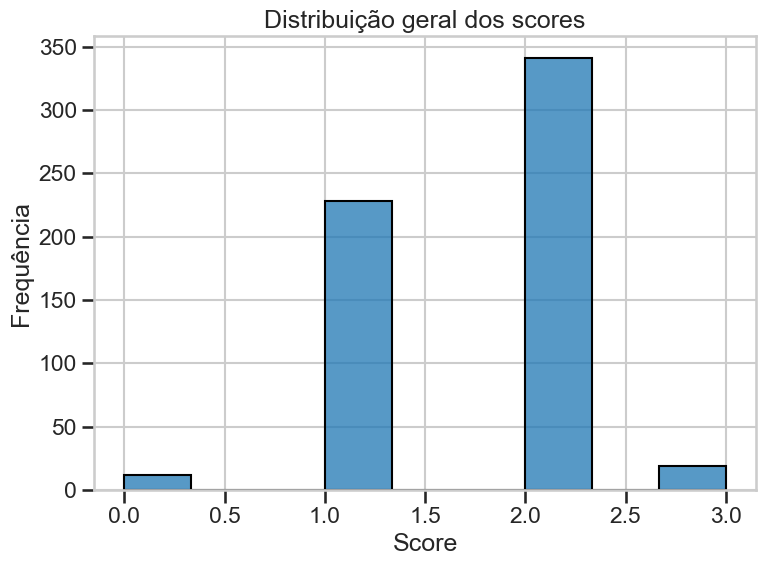

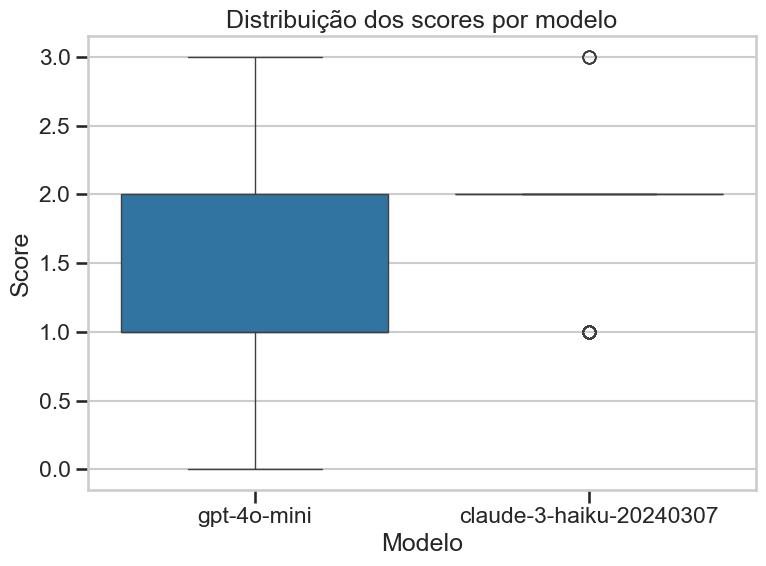

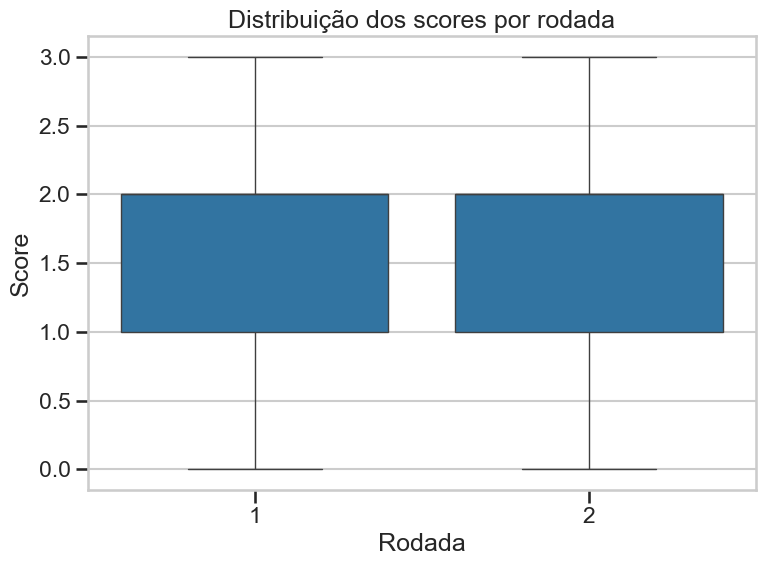

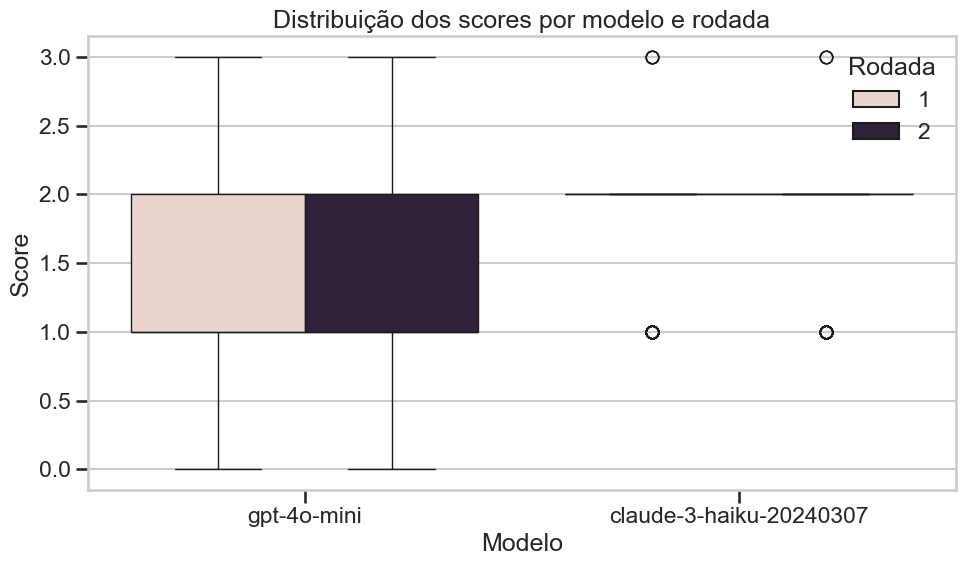

In [11]:
# Histograma geral dos scores
plt.figure(figsize=(8, 6))
sns.histplot(df_valid["score"], bins=9, kde=False)
plt.title("Distribuição geral dos scores")
plt.xlabel("Score")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "hist_scores_geral.png", dpi=300)
plt.show()

# Boxplot dos scores por modelo
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_valid, x="modelo", y="score")
plt.title("Distribuição dos scores por modelo")
plt.xlabel("Modelo")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "box_scores_por_modelo.png", dpi=300)
plt.show()

# Boxplot dos scores por rodada
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_valid, x="rodada", y="score")
plt.title("Distribuição dos scores por rodada")
plt.xlabel("Rodada")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "box_scores_por_rodada.png", dpi=300)
plt.show()

# Boxplot por modelo e rodada
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_valid, x="modelo", y="score", hue="rodada")
plt.title("Distribuição dos scores por modelo e rodada")
plt.xlabel("Modelo")
plt.ylabel("Score")
plt.legend(title="Rodada")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "box_scores_por_modelo_rodada.png", dpi=300)
plt.show()

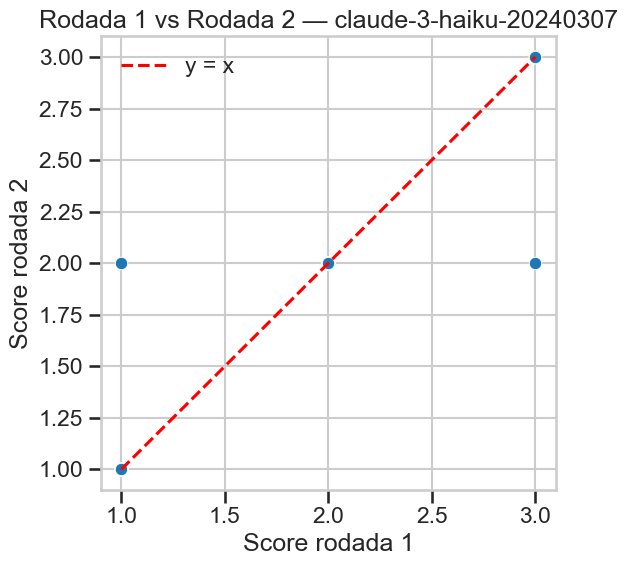

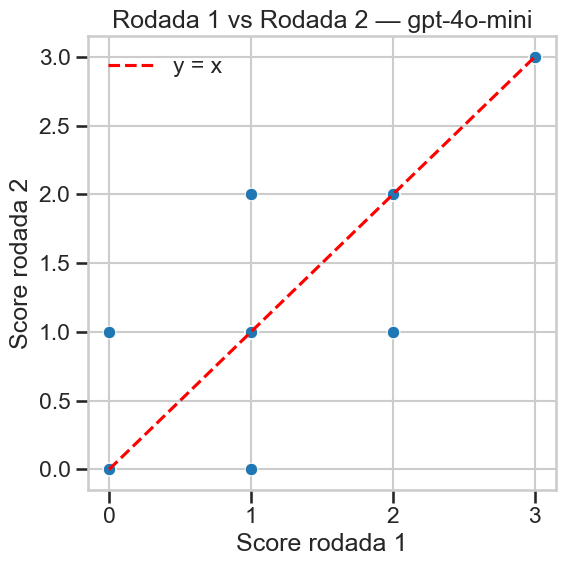

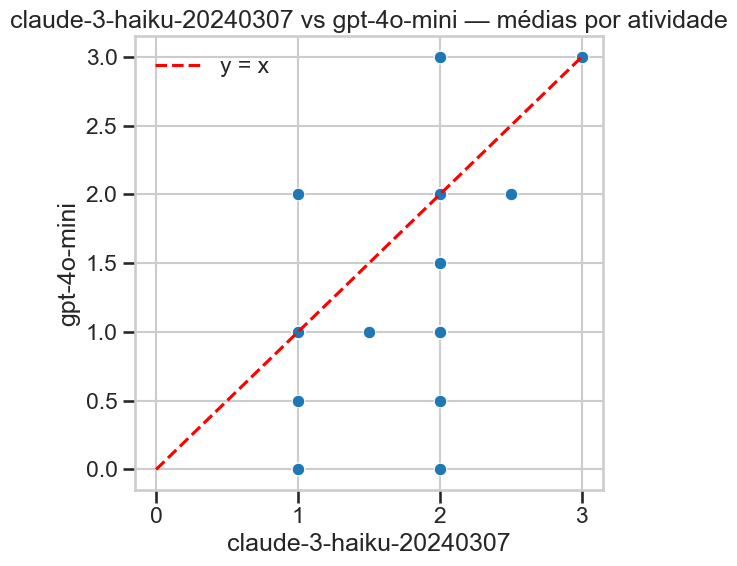

In [12]:
# Gráficos de dispersão: rodada 1 vs rodada 2 para cada modelo
for modelo, wide in res_intra.items():
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x="score_r1", y="score_r2", data=wide)
    min_val = min(wide[["score_r1", "score_r2"]].min())
    max_val = max(wide[["score_r1", "score_r2"]].max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", label="y = x")
    plt.title(f"Rodada 1 vs Rodada 2 — {modelo}")
    plt.xlabel("Score rodada 1")
    plt.ylabel("Score rodada 2")
    plt.legend()
    plt.tight_layout()
    fname = OUTPUT_DIR_GRAFICOS / f"scatter_r1_r2_{modelo}.png"
    plt.savefig(fname, dpi=300)
    plt.show()

# Gráfico de dispersão: modelo 1 vs modelo 2 (médias por atividade)
plt.figure(figsize=(6, 6))
sns.scatterplot(x=m1, y=m2, data=df_modelos_wide)
min_val = min(df_modelos_wide[[m1, m2]].min())
max_val = max(df_modelos_wide[[m1, m2]].max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="y = x")
plt.title(f"{m1} vs {m2} — médias por atividade")
plt.xlabel(m1)
plt.ylabel(m2)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "scatter_modelos_medias.png", dpi=300)
plt.show()

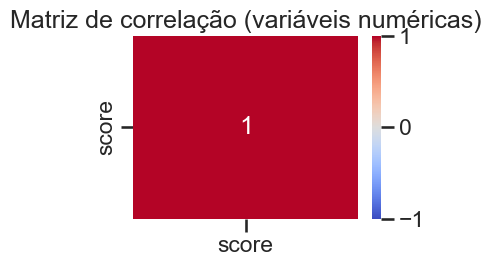

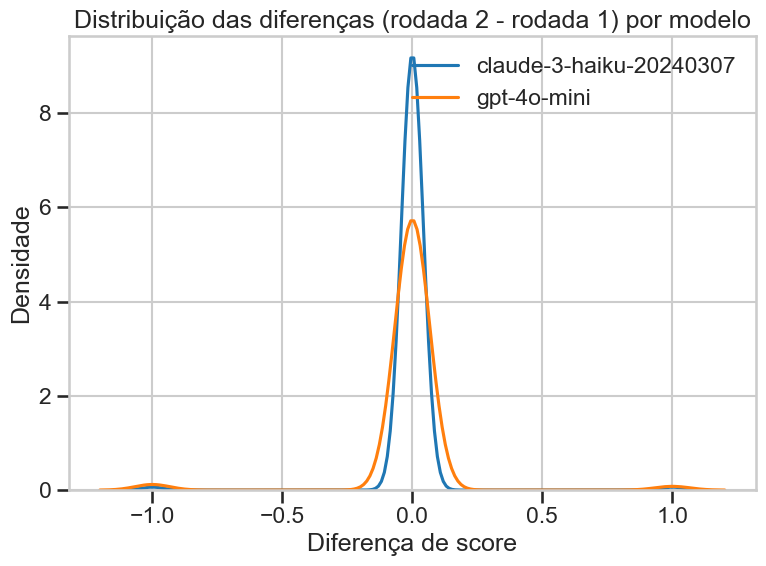

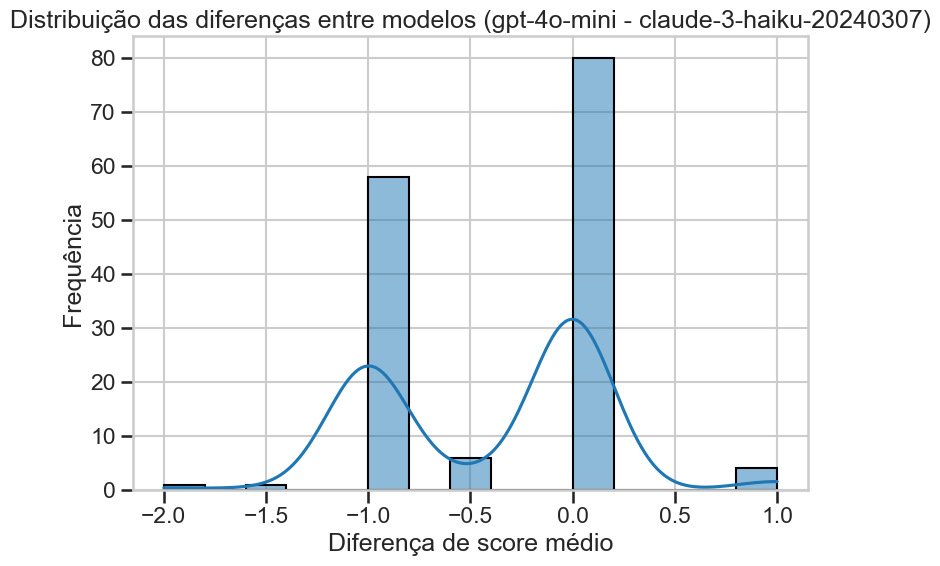

In [13]:
# Heatmap de correlação entre variáveis numéricas relevantes
corr_df = df_valid[["score"]].copy()
corr = corr_df.corr()
plt.figure(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação (variáveis numéricas)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "heatmap_correlacao.png", dpi=300)
plt.show()

# Distribuição das diferenças entre rodadas (intra-modelo)
plt.figure(figsize=(8, 6))
for modelo, wide in res_intra.items():
    sns.kdeplot(wide["diff"], label=f"{modelo}")
plt.title("Distribuição das diferenças (rodada 2 - rodada 1) por modelo")
plt.xlabel("Diferença de score")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "densidade_diffs_intra_modelo.png", dpi=300)
plt.show()

# Distribuição das diferenças entre modelos (médias por atividade)
plt.figure(figsize=(8, 6))
sns.histplot(df_modelos_wide["diff_modelos"], bins=15, kde=True)
plt.title(f"Distribuição das diferenças entre modelos ({m2} - {m1})")
plt.xlabel("Diferença de score médio")
plt.ylabel("Frequência")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "hist_diffs_entre_modelos.png", dpi=300)
plt.show()

modelo,claude-3-haiku-20240307,gpt-4o-mini,diff_modelos,diff_modelos_abs
id_atividade,,,,
Jornalista | Ler livros,2.0,0.0,-2.0,2.0
"Operador de máquinas fixas, em geral | Trabalhar com atenção",2.0,0.5,-1.5,1.5
Analista de logistica | Demonstrar capacidade de iniciativa,2.0,1.0,-1.0,1.0
Analista de desenvolvimento de sistemas | Elaborar dicionário de dados,2.0,3.0,1.0,1.0
Administrador | Trabalhar em equipe,2.0,1.0,-1.0,1.0
Advogado | Agir com ética,1.0,0.0,-1.0,1.0
Analista de logistica | Demonstrar capacidade de administrar o tempo,2.0,1.0,-1.0,1.0
Analista de pesquisa de mercado | Demonstrar capacidade de abstração,2.0,1.0,-1.0,1.0
Desenhista industrial gráfico (designer gráfico) | Solicitar parecer de outros profissionais,2.0,1.0,-1.0,1.0


C:\Users\lipef\AppData\Local\Temp\ipykernel_25808\3829899853.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


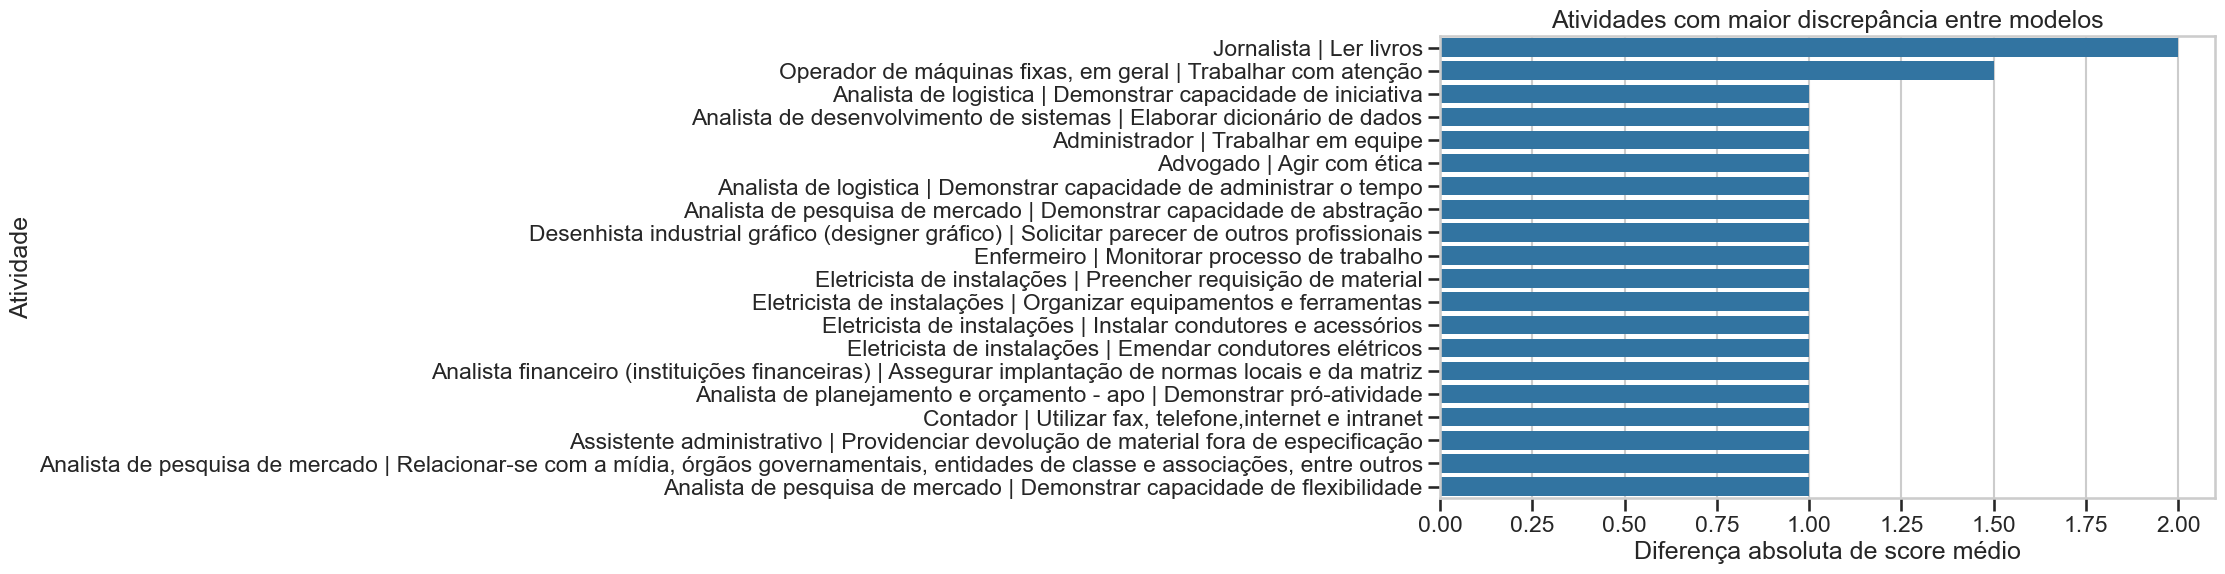

C:\Users\lipef\AppData\Local\Temp\ipykernel_25808\3829899853.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


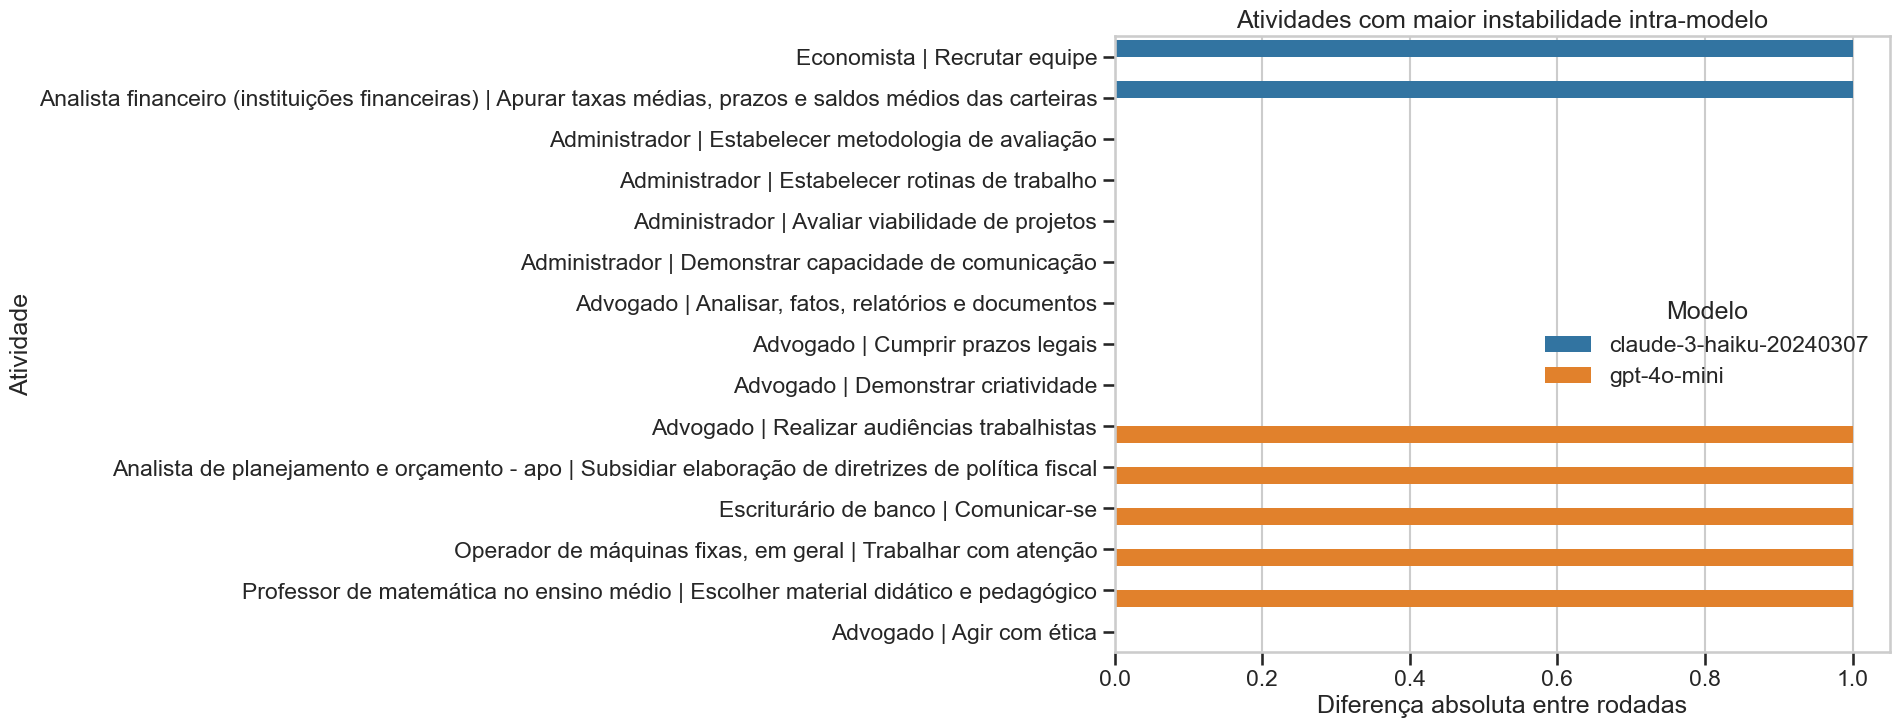

In [14]:
# Atividades com maior discrepância entre modelos
df_top_diff_modelos = df_modelos_wide.sort_values("diff_modelos_abs", ascending=False).head(20)
display(df_top_diff_modelos)
df_top_diff_modelos.to_csv(OUTPUT_DIR_TABELAS / "atividades_maior_discrepancia_entre_modelos.csv")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_top_diff_modelos.reset_index(),
    x="diff_modelos_abs",
    y="id_atividade",
)
plt.title("Atividades com maior discrepância entre modelos")
plt.xlabel("Diferença absoluta de score médio")
plt.ylabel("Atividade")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "bar_atividades_maior_discrepancia_modelos.png", dpi=300)
plt.show()

# Atividades com maior instabilidade intra-modelo (já calculadas em df_top_instaveis)
plt.figure(figsize=(10, 8))
sns.barplot(
    data=df_top_instaveis.reset_index(),
    x="diff_abs",
    y="id_atividade",
    hue="modelo",
)
plt.title("Atividades com maior instabilidade intra-modelo")
plt.xlabel("Diferença absoluta entre rodadas")
plt.ylabel("Atividade")
plt.legend(title="Modelo")
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "bar_atividades_maior_instabilidade_intra_modelo.png", dpi=300)
plt.show()

### Comparação direta das respostas médias entre modelos

Gráficos focados nas atividades com maior discrepância entre os dois modelos (média das 2 rodadas por modelo), para visualizar alinhamento e divergências sem interpretar como equivalência de magnitude global.

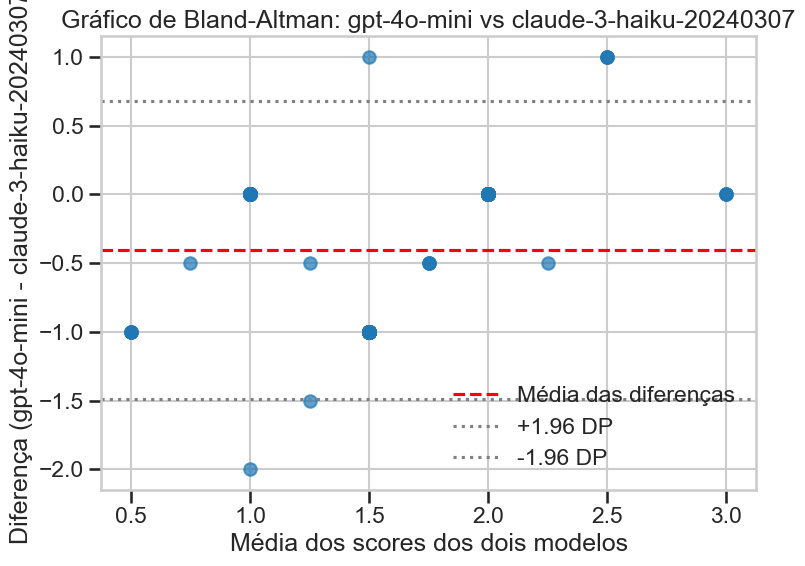

In [15]:
# Bland-Altman plot para comparação entre modelos (médias por atividade)
mean_scores = (scores_m1 + scores_m2) / 2
diff_scores = scores_m2 - scores_m1

plt.figure(figsize=(8, 6))
plt.scatter(mean_scores, diff_scores, alpha=0.7)
plt.axhline(diff_scores.mean(), color="red", linestyle="--", label="Média das diferenças")
plt.axhline(diff_scores.mean() + 1.96 * diff_scores.std(ddof=1), color="gray", linestyle=":", label="+1.96 DP")
plt.axhline(diff_scores.mean() - 1.96 * diff_scores.std(ddof=1), color="gray", linestyle=":", label="-1.96 DP")
plt.title(f"Gráfico de Bland-Altman: {m2} vs {m1}")
plt.xlabel("Média dos scores dos dois modelos")
plt.ylabel(f"Diferença ({m2} - {m1})")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR_GRAFICOS / "bland_altman_modelos.png", dpi=300)
plt.show()

_Interpretação breve_: Os gráficos ajudam a visualizar padrões que podem não ser óbvios nas tabelas, como assimetrias na distribuição de scores, presença de outliers, instabilidade concentrada em determinadas atividades e possíveis viéses sistemáticos entre modelos.

### 10. Síntese de resultados e saídas finais

Nesta seção consolidamos os principais indicadores em uma tabela-resumo e registramos uma interpretação geral em linguagem acadêmica, de forma sucinta.

In [16]:
# Tabela-resumo de principais indicadores
resumo = {}

# Estatísticas gerais
resumo["score_media_geral"] = stats_gerais["mean"]
resumo["score_mediana_geral"] = stats_gerais["median"]
resumo["score_dp_geral"] = stats_gerais["std"]

# Intra-modelo
for _, row in df_intra_summary.iterrows():
    modelo = row["modelo"]
    resumo[f"intra_{modelo}_mae"] = row["mae"]
    resumo[f"intra_{modelo}_rmse"] = row["rmse"]
    resumo[f"intra_{modelo}_corr_r1_r2"] = row["corr_r1_r2"]

# Entre modelos
resumo["entre_modelos_mae"] = res_between_models["mae"]
resumo["entre_modelos_rmse"] = res_between_models["rmse"]
resumo["entre_modelos_corr_medias"] = res_between_models["corr_medias"]

# Concordância
resumo.update({
    "pearson_r": pearson_corr,
    "spearman_rho": spearman_corr,
    "concordancia_exata": concord_exata,
    "concordancia_tol_0_5": concord_tol_05,
    "concordancia_tol_1_0": concord_tol_10,
})

df_resumo_final = pd.Series(resumo).to_frame("valor")
display(df_resumo_final)
df_resumo_final.to_csv(OUTPUT_DIR_TABELAS / "resumo_principal_indicadores.csv")

,valor
score_media_geral,1.611667
score_mediana_geral,2.000000
score_dp_geral,0.584323
intra_claude-3-haiku-20240307_mae,0.013333
intra_claude-3-haiku-20240307_rmse,0.115470
intra_claude-3-haiku-20240307_corr_r1_r2,0.966958
intra_gpt-4o-mini_mae,0.033333
intra_gpt-4o-mini_rmse,0.182574
intra_gpt-4o-mini_corr_r1_r2,0.958586
entre_modelos_mae,0.456667


#### Interpretação geral (para uso no texto do TCC)

- As estatísticas descritivas indicam o nível médio de exposição estimada pelos modelos e a dispersão dos scores em toda a amostra de atividades ocupacionais.
- As análises intra-modelo mostram em que medida cada LLM é estável ao reavaliar a mesma atividade em rodadas distintas; valores baixos de MAE e RMSE, combinados com alta correlação entre rodadas, sugerem maior reprodutibilidade.
- As comparações entre modelos revelam se há viés sistemático (diferença média) e quão próximos estão os scores atribuídos às mesmas atividades, tanto em termos de magnitude (MAE/RMSE) quanto de ordenação (correlações) e concordância em escala discreta.
- Os testes estatísticos fornecem evidência formal sobre a significância das diferenças observadas entre rodadas e entre modelos, enquanto os gráficos ajudam a identificar padrões específicos, como atividades especialmente instáveis ou com grande discrepância entre LLMs.

Esses resultados podem ser incorporados à discussão do TCC para qualificar a interpretação do índice de exposição ocupacional, destacando a confiabilidade das avaliações e as diferenças sistemáticas entre modelos de LLM.

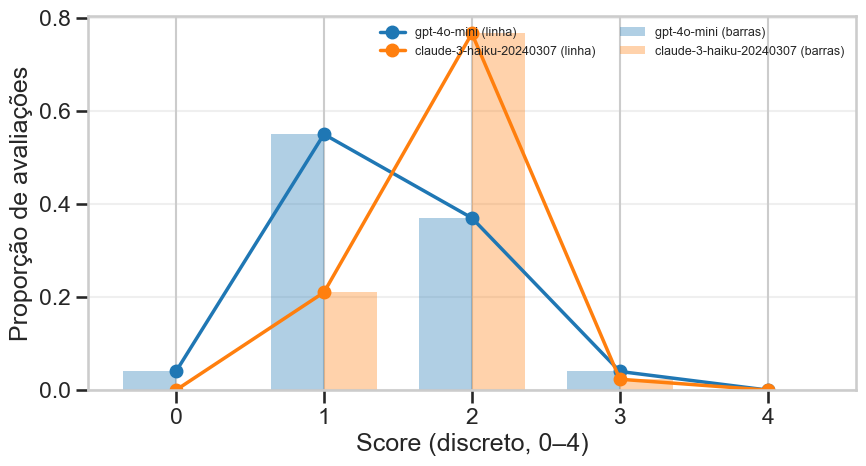

Gráfico salvo em: c:\Users\lipef\OneDrive\TCC\dados_cbo\resultados\distribuicao_scores_por_modelo_barras_linha.png


In [17]:
# Gráfico único: distribuição dos scores por modelo (barras + linha)
# Lê `score_results.csv` e compara `gpt-4o-mini` vs `claude-3-haiku-20240307`.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Localiza o root do projeto para ler `dados/score_results.csv`
input_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
input_path = None
for c in input_candidates:
    candidate = c / "dados" / "score_results.csv"
    if candidate.exists():
        input_path = candidate
        break
if input_path is None:
    raise FileNotFoundError("Não foi possível localizar `dados/score_results.csv`.")

df_scores = pd.read_csv(input_path, encoding="utf-8")
# Padroniza nomes de colunas e converte score para numérico
df_scores.columns = df_scores.columns.str.strip()
df_scores["score"] = pd.to_numeric(df_scores["score"], errors="coerce")
df_scores = df_scores.dropna(subset=["score"]).copy()

MODEL_GPT = "gpt-4o-mini"
MODEL_CLAUDE = "claude-3-haiku-20240307"

models_to_plot = [MODEL_GPT, MODEL_CLAUDE]
df_plot = df_scores[df_scores["modelo"].isin(models_to_plot)].copy()

if df_plot.empty:
    raise ValueError(
        "Nenhuma linha encontrada em score_results.csv para os modelos esperados. "
        f"Modelos encontrados: {sorted(df_scores['modelo'].unique())}"
    )

# O score esperado é discreto (0 a 4). Para ser robusto a variações como 2.00, 2.0 etc.
# arredondamos para o inteiro mais próximo.
df_plot["score_discreto"] = df_plot["score"].round().astype(int)

score_categories = [0, 1, 2, 3, 4]

# Proporções por score (para comparar mesmo se houver contagens ligeiramente diferentes)
prop = (
    df_plot.groupby(["modelo", "score_discreto"])  # conta por categoria
    ["score_discreto"]
    .size()
    .rename("n")
    .reset_index()
)

# Garantir que todas as categorias existam (mesmo com 0 ocorrências)
rows = []
for m in models_to_plot:
    sub = prop[prop["modelo"] == m].set_index("score_discreto")["n"]
    total = sub.sum() if len(sub) else 0
    for s in score_categories:
        n = int(sub.get(s, 0)) if len(sub) else 0
        rows.append({"modelo": m, "score_discreto": s, "n": n, "prop": (n / total) if total else 0.0})

plot_df = pd.DataFrame(rows)

# Plot: barras (proporção) + linha (proporção) para cada modelo
fig, ax = plt.subplots(figsize=(9, 5))

x = np.array(score_categories)
width = 0.36
offsets = {MODEL_GPT: -width/2, MODEL_CLAUDE: width/2}
colors = {MODEL_GPT: "#1f77b4", MODEL_CLAUDE: "#ff7f0e"}

for m in models_to_plot:
    sub = plot_df[plot_df["modelo"] == m].sort_values("score_discreto")
    x_pos = x + offsets[m]

    # Barras: proporção de cada score discreto
    ax.bar(
        x_pos,
        sub["prop"].values,
        width=width,
        alpha=0.35,
        color=colors[m],
        label=f"{m} (barras)"
    )

    # Linha: proporção por score discreto
    ax.plot(
        x,
        sub["prop"].values,
        color=colors[m],
        linewidth=2.5,
        marker="o",
        label=f"{m} (linha)"
    )

ax.set_xticks(x)
ax.set_xlabel("Score (discreto, 0–4)")
ax.set_ylabel("Proporção de avaliações")

ax.grid(True, axis="y", alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()

# Salvar (se OUTPUT_DIR existir no notebook); caso contrário, salva no diretório atual
save_dir = globals().get("OUTPUT_DIR", Path.cwd())
save_path = Path(save_dir) / "distribuicao_scores_por_modelo_barras_linha.png"
fig.savefig(save_path, dpi=300)
plt.show()
print(f"Gráfico salvo em: {save_path}")